# Adaline
* **perceptron**: valuta la soluzione e la accetta o rigetta (di conseguenza aggiorna i pesi), in base all'etichetta prevista
* **adaline**: voglio minimizzare l'errore, guardando una funzione di costo.
* **funzione attivazione**: $\phi(z)$ con $z= w\cdot x$ e' l'input di rete. usiamo $\phi$ funzione identita, dunque $\phi(w \cdot x)= w \cdot x$ 
* * **a che serve?** e' una funzione che determina l'attivazione del neurone in base all'output 
* * **valutazione**: se $\phi(x \cdot x)$ e' positiva allora valuto $x$ come $+1$, altrimenti $-1$
* * **errore**: usiamo $J(w)$ errore quadratico, se $J(w) \sim 0$ allora $w \cdot x \sim y$

$$
J(w) = \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

**Attenzione**: i valori di $w\cdot x^{(i)}$ grandi in modulo fanno aumentare l'errore anche se la classificazione è corretta. Quindi, in questo caso, non si miinimizza l'errore quanto piuttosto la distanza tra i valori predetti ed il target.
* **quindi**: il miglior separatore potrebbe avere un errore grande a causa della potenza



## Discesa del gradiente: gia visto

Troviamo $w^*$ che minimizza $J(w)$ utilizzando l'algoritmo di discesa del gradiente. Quindi

$$
w \leftarrow w + \Delta w = w -\eta \nabla J(w)
$$

Andiamo a calcolare il valore dei componenti di $\nabla J(w)$.

$$
\frac{\partial J}{\partial w_j} = \frac{\partial}{\partial w_j} \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

$$
= \frac{1}{2}\sum_{i=1}^n 2  \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - w\cdot x^{(i)} \right)
$$

$$
 = \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - \sum_{k=1}^{d}w_k\cdot x^{(i)}_k \right)
$$

$$
= \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)(-x^{(i)}_j)
$$

$$
=-\sum_{i=1}^n x^{(i)}_j \left( y^{(i)} - w\cdot x^{(i)} \right)
$$

La precedente è uguale al prodotto scalare del vettore colonna $j$ di $X$ per il vettore

$$
\texttt{errors} = \left(
\begin{array}{c}
y^{(1)}-w\cdot x^{(1)}\\
\vdots\\
y^{(n)}-w\cdot x^{(n)}
\end{array}
\right)
$$

quindi

$$
\nabla J(w) = - X^T\times \texttt{errors}
$$

Dove il precedente è un prodotto matrice-vettore.


```python
'''
Parametri: X, matrice di addestramento; y, vettore etichette; eta, tasso di apprendimento;
'''
        for _ in range(max_num_iterations):
            errors = (y -  np.dot(X, w[1:]) + w[0] )
            w[1:] += eta * X.T.dot(errors)
            w[0]  += eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            costs.append(cost)
```

L'aggiornamento di `w[0]` si spiega con il valore pari a `1` relativo alla variabile fittizia il cui peso è il termine noto. Questo induce una colonna di `1` della matrice $X$ (una riga in $X^T$).



## Differenza con perceptron


![immagine](13-confronto_schema.png)
* **perceptron**: la soluzione e' accettata solo se non ci sono errori, usiamo una funzioine a soglia che confronta soluzione con valore atteso.
* **adaline**: funzione di attivazione, ha dominio nei reali, calcola l'errore da minimizzare.

### Aggiornamento dei pesi
Le regole di addestramento possono essere riassunte come segue
**Perceptron:**

$$w_j \leftarrow w_j + \eta (y^{(i)} - \hat{y}^{(i)}) x_j^{(i)}$$

dove $\hat{y}^{(i)}$ è l'etichetta prevista.

**Adaline (Adaptive Linear Neuron):**

$$w_j \leftarrow w_j + \eta \sum_{i=1}^{n} (y^{(i)} - w\cdot x^{(i)}) x_j^{(i)}$$

La struttura si somiglia, la più grossa differenza è che $\hat{y}^{(i)}$ è un'etichetta, mentre $w\cdot x^{(i)}$ è un numero reale,e sto guardando l'errore globale


##  Iperparametri

La convergenza dell'algoritmo discesa del gradiente è garantita da:
* continutità e convessità della funzione. 
* tutta via, dipende da:
* * **numero di epoche massime**
* * **tasso di apprendimento** $\eta$.

**2 casi brutali**:
* $\eta$ troppo grande: l'algoritmo salta il minimi e non converge
* $\eta$ troppo piccolo: non ci arrivo usando il numero di epoche massime.

![immagine](13-iperparametri.png)

**oss.**: a differenza del perceptron, l'obiettivo e' sbagliare il meno possibile in caso l'istanza non sia linearmente separabile. con adaline sto minimizzando l'errore anche se non posso risolvere l'istanza.

# differenza tra adaline e perceptron
nel perceptron:
```python
for _ in range(self.n_iter):
    errors = 0
    for xi, target in zip(X, y):
        if target*self.net_input(xi) <= 0:
            self.w_[1:] += self.eta*xi*target
            self.w_[0] += self.eta*target
            errors += 1
    self.errors_.append(errors)
    if errors == 0:
        break
return self
```

in adaline:
```python
for i in range(self.n_iter):
    net_input = self.net_input(X)
    
    output = self.activation(net_input)
    errors = (y - output)
    self.w_[1:] += self.eta * X.T.dot(errors)
    self.w_[0] += self.eta * errors.sum()
    cost = (errors**2).sum() / 2.0
    self.cost_.append(cost)
```

In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')


# select setosa and versicolor
y = df.iloc[0:100, 4].values
# rimappa le etichette in -1 e 1
y = np.where(y == 'Iris-setosa', -1, 1)

# extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

## Codice classe: ADALINE

In [58]:
class AdalineGD(object):
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Sum-of-squares cost function value in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Please note that the "activation" method has no effect
            # in the code since it is simply an identity function. We
            # could write `output = self.net_input(X)` directly instead.
            # The purpose of the activation is more conceptual, i.e.,  
            # in the case of logistic regression (as we will see later), 
            # we could change it to
            # a sigmoid function to implement a logistic regression classifier.

            # ossia la funzione identita
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

In [59]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02, labels = None):

    if labels == None:
        labels = {}
        for lab in np.unique(y):
            labels[lab] = lab
    
    # setup marker generator and color map
    markers = ('s', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=labels[cl], 
                    edgecolor='black')

Text(0.5, 1.0, 'Adaline - Learning rate 0.0001')

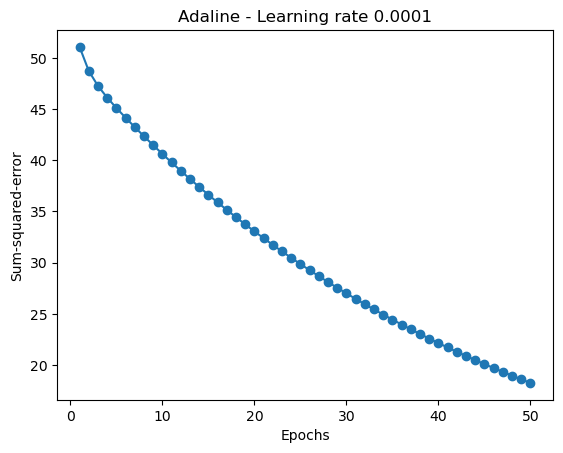

In [60]:
ada3 = AdalineGD(n_iter=50, eta=0.0001).fit(X, y)
plt.plot(range(1, len(ada3.cost_) + 1), ada3.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline - Learning rate 0.0001')

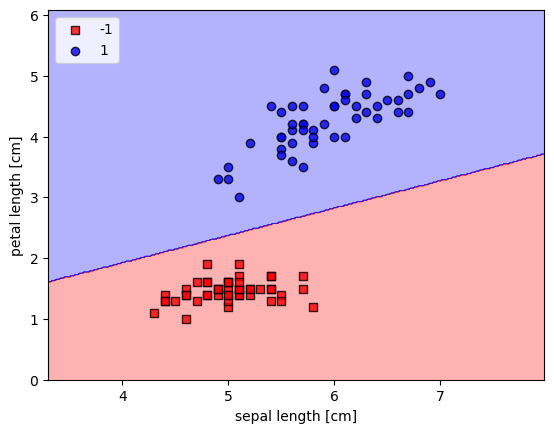

In [61]:
plot_decision_regions(X, y, classifier=ada3)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

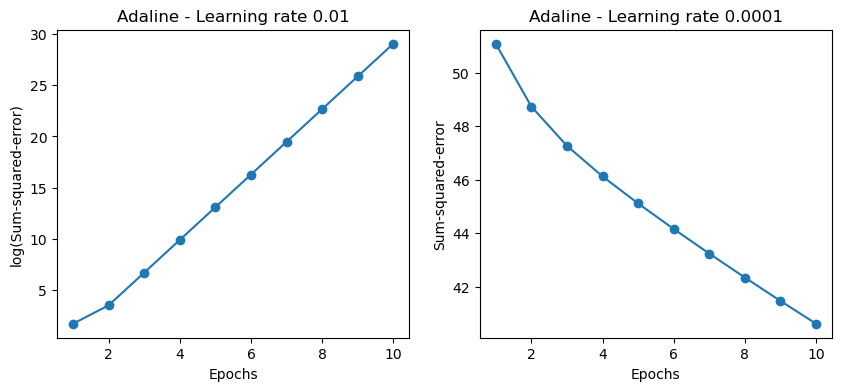

In [62]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# esempio con tasso di apprendimento molto grande
ada1 = AdalineGD(n_iter=10, eta=0.01).fit(X, y)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Sum-squared-error)')
ax[0].set_title('Adaline - Learning rate 0.01')

# esempio con tasso di apprendimento "giusto"
ada2 = AdalineGD(n_iter=10, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.cost_) + 1), ada2.cost_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Sum-squared-error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

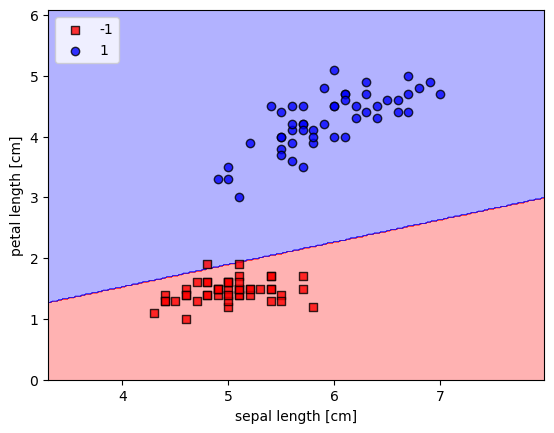

In [63]:
# provare con ada1, ada2 e ada3

ada3 = AdalineGD(n_iter=20, eta=0.0001).fit(X, y)

plot_decision_regions(X, y, classifier=ada3)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

# Logistic Regression
Siano:
* **vett. features**: $x$
* **vett. coefficienti**: $w$
* $w \cdot x = z$ varia in $(-\infty, +\infty)$
* **obiettivo**: introdurre una misura di probabilita nel conteggio

Idea: legare questo valore ad una probabilità in modo da avere una misura sulla bontà di una classificazione basata su una probabilità.

Sia: 
* $p$ probabilta della classe classificata con $+1$
* $p=Pr(y=1|x)$ ovvero la probabilità che se le features sono $x$ la classe è $+1$.

**Odd**:
$$
\frac{p}{1-p} \in [0,+\infty]
$$
**passando al logaritmo**:
$$
\text{logit}(p) = \log \left(\frac{p}{1-p}\right) \in [-\infty,+\infty]
$$

**a cosa serve**? posso modellare il valore $z$ usando il logaritmo di Odds, in quanto assume valori in $[-\infty,+\infty]$
* $z$ e' output di rete (???)

$$
\text{logit}(p) = \log \left(\frac{p}{1-p}\right) \leftarrow w\cdot x = z
$$


**funzione sigmoide logistica**. Da questa assunzione possiamo esprimere il valore di $p$ in funzione di $w\cdot x$:
$$
\begin{array}{c}
\frac{p}{1-p} = e^z\\
\downarrow\\
p(1 + e^z)=e^z\\
\downarrow\\
p = \frac{1}{1+e^{-z}}
\end{array}
$$

La precedente è chiamata **funzione sigmoide logistica**






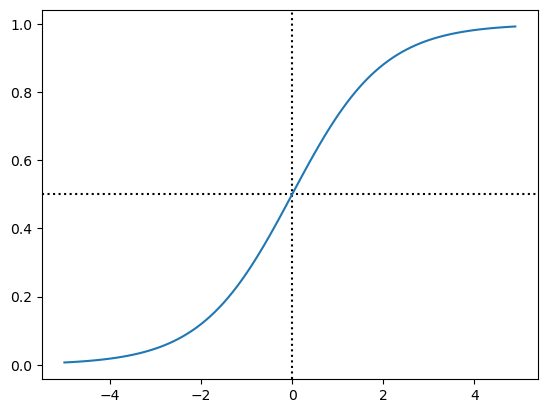

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1/(1+np.exp(-z))

plt.axvline(0.0, color='k', linestyle=':')
plt.axhline(0.5, color='k', linestyle=':')

z = np.arange(-5, 5, 0.1)
phi_z = sigmoid(z)

plt.plot(z, phi_z)



**ridefiniamo funzione di attivazione**:
usando $p=\frac{1}{1+e^{-z}}$
$$
\phi(w\cdot x) = \frac{1}{1+e^{w\cdot x}} = Pr(y=1|x) \in [0,1]
$$

**soglia di classificazione** basata sulla nuova attivazione:
$$
\hat{y}(w\cdot x) = \left\{ \begin{array}{lcl}
+1 & & \text{se}\quad \phi(w\cdot x) > 0.5\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

**oss**: seconda classe è $0$ e non $-1$, sarà chiarito in seguito.

Tenendo conto dell'andamento della funzione sigmoidale, la precedente espressione è equivalente a

$$
\hat{y}(w\cdot x) = \left\{ \begin{array}{lcl}
+1 & & \text{se}\quad w\cdot x > 0\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

che è la stessa funzione funzione a soglia utilizzata per Adaline.

## Apprendimento dei pesi

Si consideri la seguente espressione

$$
(*) \quad\quad\quad\quad \phi(w\cdot x^{(i)})^{y^{(i)}}(1-\phi(w\cdot x^{(i)}))^{1-y^{(i)}}
$$

- Se $y^{(i)} = 1$, allora $(*) = \phi(w\cdot x^{(i)}) = Pr(y^{(i)} = 1| x)$
- Se $y^{(i)} = 0$, allora $(*) = 1-\phi(w\cdot x^{(i)}) = Pr(y^{(i)} =  0| x)$
- Cosa misura $(*)$? La probabilità che l'esempio $i$ venga classificato correttamente

La precedente trattazione spiega anche il motivo del perché la seconda è indicata con  $0$.

**funzione di verosimiglianza**: assumo esempi indipendenti gli uni dagli altri, allora la probabilita di classificare tutti gli esempi e':
$$
\prod_{i=1}^{n} \phi(w\cdot x^{(i)})^{y^{(i)}}(1-\phi(w\cdot x^{(i)}))^{1-y^{(i)}}
$$

**massimizzare**: questa e' la funzione che voglio massimizzare
 
**funzione di log-verosimiglinza**: 
* Equivalentemente massimizzeremo il suo logaritmo naturale, ovvero la funzione 
* L'obbiettivo è trovare $w$ che massimizzi la precedente espressione.
$$
\sum_{i=1}^{n}\left( y^{(i)}\log\left(\phi(w\cdot x^{(i)})\right) + (1-y^{(i)})\log\left( 1-\phi(w\cdot x^{(i)})\right) \right)
$$

Cambiando di segno la precedente diventa una funzione di costo differenziabile e che può essere minimizzata con discesa del gradiente.

$$
J(w) = -\sum_{i=1}^{n}\left( y^{(i)}\log\left(\phi(w\cdot x^{(i)})\right) + (1-y^{(i)})\log\left( 1-\phi(w\cdot x^{(i)})\right) \right) = -\sum_{i=1}^{n} \ell_i(w)
$$

dove abbiamo indicato con $\ell_i(w)$ la $i$-esima funzione nella sommatoria.

**ESAME**: il prof non chiede tutti i passaggi!

$$
\frac{d}{d w_j}\ell_i(w) = \frac{y^{(i)}}{\phi(w\cdot x^{(i)})} \frac{d}{d w_j} \phi(w\cdot x^{(i)})+
\frac{1-y^{(i)}}{1-\phi(w\cdot x^{(i)})} \left(0 - \frac{d}{d w_j}\phi(w\cdot x^{(i)}) \right)
$$

$$
= \left( \frac{y^{(i)}}{\phi(w\cdot x^{(i)})} - \frac{1-y^{(i)}}{1-\phi(w\cdot x^{(i)})}\right) \frac{d}{d w_j}\phi(w\cdot x^{(i)})
$$

$$
= \frac{y^{(i)} - \phi(w\cdot x^{(i)}) }{\phi(w\cdot x^{(i)}) \left(1-\phi(w\cdot x^{(i)})\right)} \frac{d}{d w_j}\phi(w\cdot x^{(i)})
$$

Per proseguire abbiamo bisogno della derivata parziale di $\phi(w\cdot x^{(i)})$ rispetto a $w_j$.

$$
\frac{d}{d w_j}\phi(w\cdot x^{(i)}) = \frac{d}{d w_j}\frac{1}{1+e^{-w\cdot x^{(i)}}}
$$

applichiamo la regola della derivata del quoziente

$$
= \frac{0(1+e^{-w\cdot x^{(i)}}) - 1(\frac{d}{d w_j}(1+e^{-w\cdot x^{(i)}})) }{\left( 1+e^{-w\cdot x^{(i)}} \right)^2}
$$

Tenendo conto che

$$
\frac{d}{d w_j} e^{-w\cdot x^{(i)}} = e^{-w\cdot x^{(i)}} \frac{d}{d w_j}\left(-w_j\cdot x^{(i)}_j \right) = 
-x_j^{(i)} e^{-w\cdot x^{(i)}}
$$

allora

$$
\frac{d}{d w_j}\phi(w\cdot x^{(i)}) = \frac{x_j^{(i)} e^{-w\cdot x^{(i)}}}{\left( 1+e^{-w\cdot x^{(i)}} \right)^2} = x_j^{(i)} \phi(w\cdot x^{(i)}) \frac{e^{-w\cdot x^{(i)}}}{1+e^{-w\cdot x^{(i)}}}
$$

$$
= x_j^{(i)} \phi(w\cdot x^{(i)}) (1- \phi(w\cdot x^{(i)}))
$$

Sostituendo all'espressione per $\frac{d}{d w_j}\ell_i(w)$

$$
\frac{d}{d w_j}\ell_i(w) = \frac{y^{(i)} - \phi(w\cdot x^{(i)}) }{\phi(w\cdot x^{(i)}) \left(1-\phi(w\cdot x^{(i)})\right)}x_j^{(i)} \phi(w\cdot x^{(i)}) (1- \phi(w\cdot x^{(i)}))
$$

$$
= x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

## aggiornare i pesi
L'aggiornamento dei pesi $w_j$ segue il verso opposto del gradiente ovvero

$$
w_j \leftarrow w_j -\eta \frac{d}{d w_j} J(w)
$$

ma

$$
\frac{d}{d w_j} J(w) = - \sum_{i=1}^{n} x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

quindi

$$
w_j \leftarrow w_j +\eta \sum_{i=1}^{n} x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

Usando le stesse considerazioni atte per Adaline

$$
w \leftarrow X^T \times \texttt{errors}
$$

Dove il vettore `errors` ha per componenti $y^{(i)} - \phi(w\cdot x^{(i)})$. Notare che quest'ultimo ha la stessa forma dell'analogo di Adaline, la differenza è nella definizione della funzione $\phi$ che nel caso di Adaline è la funzione identità mentre ora è la funzione sigmoid e logistica.

## Codice classe: Logistic Regression

Il codice e' come prima ma cambia la funzione di attivazione e qualcos'altro.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

class LogisticRegressionGD(object):
    """Logistic Regression Classifier using gradient descent.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
    
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Logistic cost function value in each epoch.

    """
    def __init__(self, eta=0.05, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            
            # note that we compute the logistic `cost` now
            # instead of the sum of squared errors cost
            cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))
            self.cost_.append(cost)
        
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        #return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
        return 1. / (1. + np.exp(-z))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)
        # equivalent to:
        # return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

# attivazione
Viene utilizzata la funzione clip per prevenire l'overflow con numeri troppo gradi (o troppo piccoli), e il degradamento delle performance.

$250$ e' giusto come valore per il clipping, poiche $e^250$ e' contenuto in un `float64`

inoltre:
* se $z=250$, allora la sigmoide e' vicinissima a `1.0`
* se $z=-250$, allora la sigmoide e' vicinissima a `0`

0.91


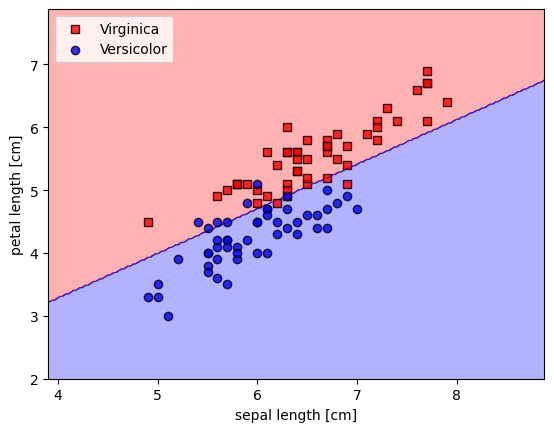

In [66]:
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
# map dei nomi delle classi
y = np.where(y == 'Iris-versicolor', 1, 0)

# extract sepal length and petal length
X = df.iloc[50:, [0, 2]].values

lgrg = LogisticRegressionGD(n_iter=1000, eta=0.001, random_state=1).fit(X, y)

# stampa e classifica
plot_decision_regions(X, y, classifier=lgrg, labels={1:'Versicolor', 0:'Virginica'})

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.savefig('iris.png', dpi=300)

accuracy = np.mean(lgrg.predict(X) == y)
print(accuracy)

# standardizzazione
Nota: invece di calcolare `mu` e `std` sull'intero dataset, li ho caclcolati solo sul `train set`. Questo perche' devo standardizzare rispetto a deviazione e media della fase di addestramento, altrimenti starei applicando sui dati la media del test set, ed e' concettualemente sbagliato.

In [67]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=1000, n_features=10,
                        n_informative=5, n_classes=2, random_state=0, shuffle=False)
# con shuffle=false, le 5 n_informative si trovano all'inizio, altrimenti sono mescolate!

# Le informative sono le prime n_informative, poi seguono le altre
X = X [:,:5]

X_train, X_test, y_train, y_test = train_test_split(X, y)

mu, std = X_train.mean(0), X_train.std(0)
X_train_std = (X_train-mu)/std
X_test_std = (X_test-mu)/std

# X_train_cur, X_test_cur = X_train, X_test
X_train_cur, X_test_cur = X_train_std, X_test_std

In [68]:
ada = AdalineGD(n_iter=5000, eta=0.0001, random_state=1)
ada.fit(X_train_cur,y_train)
accuracy = np.mean(ada.predict(X_train_cur) == y_train)
print(accuracy)
accuracy = np.mean(ada.predict(X_test_cur) == y_test)
print(accuracy)

0.5013333333333333
0.484


In [69]:
lgrg = LogisticRegressionGD(n_iter=1000, eta=0.00011, random_state=1)
lgrg.fit(X_train_cur,y_train)
accuracy = np.mean(lgrg.predict(X_train_cur) == y_train)
print(accuracy)
accuracy = np.mean(lgrg.predict(X_test_cur) == y_test)
print(accuracy)

0.8986666666666666
0.944


# esercizio 1: Stocastic Regression
Si modifichi il metodo `fit` della classe `LogisticRegressionGD` in modo da implementare la versione stocastica della disceda del gradiente.


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

class LogisticRegressionSC(object):
    """Logistic Regression Classifier using gradient descent.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
    
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Logistic cost function value in each epoch.

    """
    def __init__(self, eta=0.05, n_iter=50, batch_size=None, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.batch_size_ = batch_size

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        # definisci il batch size
        self.batch_size_ = X.shape[0] if self.batch_size_ == None else self.batch_size_

        for i in range(self.n_iter):
            shuffle_idxs = np.arange(X.shape[0])
            np.random.shuffle(shuffle_idxs)

            for b_idx in range(0,X.shape[0], self.batch_size_):
                X_b = X[shuffle_idxs[b_idx:b_idx+self.batch_size_]]
                y_b = y[shuffle_idxs[b_idx:b_idx+self.batch_size_]]

                net_input = self.net_input(X_b)
                output = self.activation(net_input)
                errors = (y_b - output)
                # invece di usare batch_size, mi prendo la grandezza di X_b
                # perche' all'ultima iterazione potrebbe essere che X_b.shape[0] < self.batch_size
                m = X_b.shape[0]
                self.w_[1:] += self.eta * X_b.T.dot(errors)/m
                self.w_[0] += self.eta * errors.sum()/m
                
                # note that we compute the logistic `cost` now
                # instead of the sum of squared errors cost
            
            # ora calcola tutto tutto tutto tutto!!@#!@#
            output = self.activation(self.net_input(X))
            cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))
            self.cost_.append(cost)
        
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        #return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
        return 1. / (1. + np.exp(-z))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)
        # equivalent to:
        # return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [77]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_classes=2, random_state=0, shuffle=False)

X = X[:,:]

X_train, X_test, y_train, y_test = train_test_split(X,y)

mu, std = X_train.mean(0), X_train.std(0)
X_train_std = (X_train-mu)/std
X_test_std = (X_test-mu)/std
# nota, non posso standardizzare l'input dell'addestra

X_train_cur, X_test_cur = X_train, X_test

In [80]:
eta = 0.001

lgrg = LogisticRegressionSC(n_iter=2000, eta=eta, random_state=6)
lgrg.fit(X_train_cur, y_train)
accuracy = np.mean(lgrg.predict(X_train_cur)== y_train)
print(accuracy)
accuracy = np.mean(lgrg.predict(X_test_cur) == y_test)
print(accuracy)
costs_GD = lgrg.cost_

lgrg_s = LogisticRegressionSC(n_iter=2000, eta=eta, random_state=6, batch_size=100)
lgrg_s.fit(X_train_cur, y_train)
accuracy = np.mean(lgrg_s.predict(X_train_cur)== y_train)
print(accuracy)
accuracy = np.mean(lgrg_s.predict(X_test_cur) == y_test)
print(accuracy)
costs_GDS = lgrg_s.cost_

0.896
0.84
0.9133333333333333
0.868


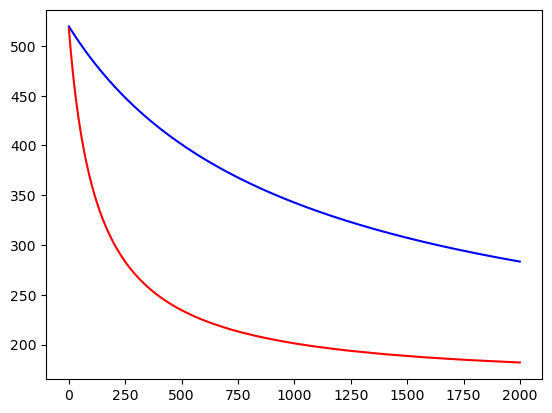

In [81]:
plt.plot(costs_GD, c='b')
plt.plot(costs_GDS, c='r')
plt.show()

## Domanda esame: Perche' la versione stocastica converge prima?
perche' anche se fatto su piccoli batch, la versione stocastica fa piu aggiornamenti in un'iterazione

Praticamente faccio $N / \text{batch\_size}$ aggiornamenti:
* i batch sono scelti in modo casuale, dunque c'e' molto rumore
* pero' la somma di tutti i pesi e' molto vantaggiosa rispetto al rumore
* il rumore e' vantaggioso: permette di uscire da minimi locali poco profondi, o dai punti di sella, li dove il normale Gradient Descent calcolerebbe una valore vicino a 0

Attenzione: 
> gradiente calcolato sull'intero dataset (Batch Gradient Descent) è la "direzione vera" verso il minimo globale (o locale) della funzione di costo. È preciso, ma lento e costoso. Quando usi un mini-batch, stai calcolando il gradiente su un campione. Poiché quel campione potrebbe non rappresentare perfettamente l'intera distribuzione (es. il batch contiene troppi dati "facili" o troppi dati "outlier"), la direzione che ottieni non è quella ottimale.

# versione online
Vorre aggiungere i campioni all'addestramento appena mi arrivano, anche se ho gia aggiornato il modello.

In [ ]:

class LogisticRegressionOnline(object):
    def fit(self, X,y, update=False):
        if not update:  
            rgen = np.random.RandomState(self.random_state)
            self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1+X.shape[1])
            self.cost_ = []

            self. batch_size = X.shape[0] if self.batch_size_ == None else self.batch_size_
        
        # ...
        # ...

    def update(self, x,y n_iter=1000):
        self.n_iter = n_iters
        self.fit(x,y,update=True)